In [ ]:
import random, numpy as np, torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = ("cuda" if torch.cuda.is_available()
else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
IMG = 64 # upscale from 64x64; use 224 on Colab if you want, but it is slower
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([transforms.Resize(IMG), transforms.RandomHorizontalFlip(),
transforms.RandomVerticalFlip(), transforms.ToTensor(), transforms.Normalize(mean, std)])
test_tf = transforms.Compose([transforms.Resize(IMG), transforms.ToTensor(),
transforms.Normalize(mean, std)])
full = datasets.EuroSAT(root="data", download=True)
classes = full.classes
print(len(full), "images,", len(classes), "classes:", classes)
tr_idx, te_idx = train_test_split(np.arange(len(full)), test_size=0.2,
stratify=full.targets, random_state=SEED)
train_ds = Subset(datasets.EuroSAT("data", transform=train_tf), tr_idx)
test_ds = Subset(datasets.EuroSAT("data", transform=test_tf), te_idx)
BS = 64 # use 32 on the Mac if memory is tight
train_dl = DataLoader(train_ds, batch_size=BS, shuffle=True, num_workers=2)
test_dl = DataLoader(test_ds, batch_size=BS, shuffle=False, num_workers=2)

27000 images, 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
def make_model(pretrained):
  w = models.ResNet18_Weights.DEFAULT if pretrained else None
  m = models.resnet18(weights=w)
  m.fc = nn.Linear(m.fc.in_features, len(classes))
  return m.to(device)

In [ ]:
@torch.no_grad()
def predict(model, dl):
  model.eval(); ys, ps = [], []
  for x, y in dl:
    ps.append(model(x.to(device)).argmax(1).cpu()); ys.append(y)
  return torch.cat(ys).numpy(), torch.cat(ps).numpy()

In [ ]:
def run(pretrained, epochs=3, lr=3e-4):
  torch.manual_seed(SEED)
  model = make_model(pretrained)
  opt = torch.optim.AdamW(model.parameters(), lr=lr)
  loss_fn = nn.CrossEntropyLoss()
  for ep in range(epochs):
    model.train(); total = 0.0
    for x, y in train_dl:
      x, y = x.to(device), y.to(device)
      opt.zero_grad(); loss = loss_fn(model(x), y); loss.backward(); opt.step()
      total += loss.item() * len(y)
    y_true, y_pred = predict(model, test_dl)
    print(f"epoch {ep+1}: train loss {total/len(train_ds):.4f} "
    f"test acc {(y_true == y_pred).mean():.4f}")
  return model, y_true, y_pred

In [ ]:
import time; t0 = time.time()
model_pre, yt, yp_pre = run(pretrained=True, epochs=5)
acc_pre = (yt == yp_pre).mean()
print(f"PRETRAINED final test accuracy: {acc_pre:.4f} ({time.time()-t0:.0f}s)")

epoch 1: train loss 0.2903 test acc 0.9443
epoch 2: train loss 0.1515 test acc 0.9615
epoch 3: train loss 0.1219 test acc 0.9696
epoch 4: train loss 0.1051 test acc 0.9609
epoch 5: train loss 0.0943 test acc 0.9581
PRETRAINED final test accuracy: 0.9581 (95s)


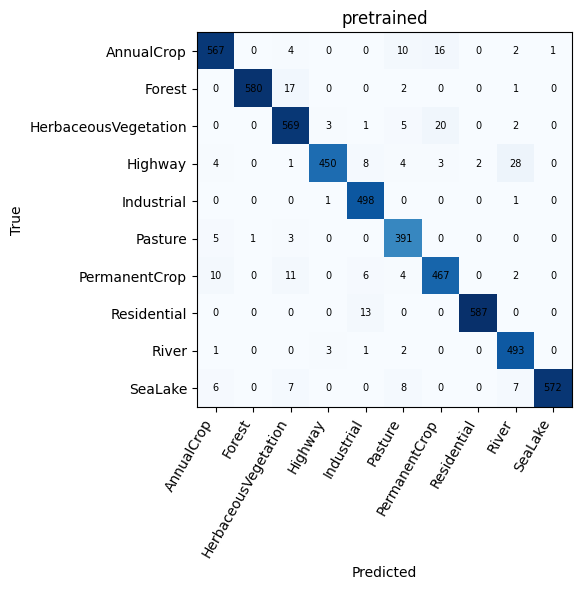

                      precision    recall  f1-score   support

          AnnualCrop      0.956     0.945     0.951       600
              Forest      0.998     0.967     0.982       600
HerbaceousVegetation      0.930     0.948     0.939       600
             Highway      0.985     0.900     0.940       500
          Industrial      0.945     0.996     0.970       500
             Pasture      0.918     0.978     0.947       400
       PermanentCrop      0.923     0.934     0.928       500
         Residential      0.997     0.978     0.987       600
               River      0.920     0.986     0.952       500
             SeaLake      0.998     0.953     0.975       600

            accuracy                          0.958      5400
           macro avg      0.957     0.959     0.957      5400
        weighted avg      0.959     0.958     0.958      5400



In [ ]:
def show_cm(y_true, y_pred, name):
  cm = confusion_matrix(y_true, y_pred)
  fig, ax = plt.subplots(figsize=(7, 6))
  ax.imshow(cm, cmap="Blues")
  ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=60, ha="right")
  ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
  for i in range(len(classes)):
    for j in range(len(classes)):
      ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7)
  ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(name)
  plt.tight_layout(); plt.savefig(f"confusion_{name}.png", dpi=150); plt.show()
show_cm(yt, yp_pre, "pretrained")
print(classification_report(yt, yp_pre, target_names=classes, digits=3))

epoch 1: train loss 0.8258 test acc 0.7165
epoch 2: train loss 0.5999 test acc 0.7628
epoch 3: train loss 0.4842 test acc 0.7831
epoch 4: train loss 0.4088 test acc 0.8457
epoch 5: train loss 0.3480 test acc 0.8843
SCRATCH final test accuracy: 0.8843 (103s)


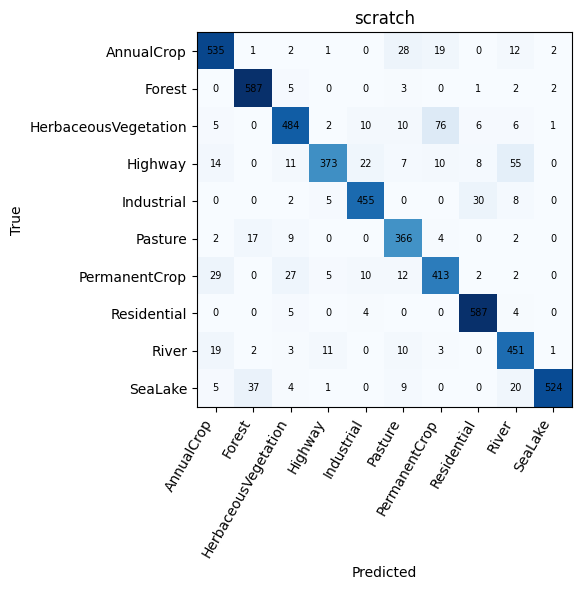

In [ ]:
t0 = time.time()
model_scr, yt, yp_scr = run(pretrained=False, epochs=5)
acc_scr = (yt == yp_scr).mean()
print(f"SCRATCH final test accuracy: {acc_scr:.4f} ({time.time()-t0:.0f}s)")
show_cm(yt, yp_scr, "scratch")